In [14]:
import pandas as pd
import pybaseball as pyb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import requests

url = "https://statsapi.mlb.com/api/v1/standings?leagueId=103,104&season=2025&standingsTypes=regularSeason"
res = requests.get(url)
data = res.json()

teams = []
for record in data['records']:
    for team in record['teamRecords']:
        teams.append({
            'Team': team['team']['name'],
            'W': team['wins'],
            'L': team['losses'],
            'R': team['runsScored'],
            'RA': team['runsAllowed']
        })

df = pd.DataFrame(teams)

#데이터 타입을 숫자로 변환
# 'W', 'L', 'R', 'RA' 컬럼을 모두 숫자(float)로 변환
cols_to_fix = ['W', 'L', 'R', 'RA']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. 기대 승률 및 Luck Factor 계산 
df['Actual_Win_Pct'] = df['W'] / (df['W'] + df['L'])
exponent = 1.83
df['Pythagorean_Win_Pct'] = (df['R']**exponent) / (df['R']**exponent + df['RA']**exponent)
df['Luck_Factor'] = df['Actual_Win_Pct'] - df['Pythagorean_Win_Pct']

# 5. 클러스터링
features = ['Actual_Win_Pct', 'Luck_Factor']
# 결측치(NaN)가 있다면 제거
df = df.dropna(subset=features)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(x_scaled)

# 6. 결과 출력
print("\n--- 2025 MLB '애매한 성적의 포텐셜 팀'  ---")
final_result = df[['Team', 'W', 'L', 'Actual_Win_Pct', 'Pythagorean_Win_Pct', 'Luck_Factor', 'Cluster']].round(3)
display(final_result.sort_values(by='Luck_Factor', ascending=True).head(10))

# 승률 0.45 ~ 0.50 사이이면서 Luck_Factor가 낮은 팀들만 따로 추출
target_teams = final_result[
    (final_result['Actual_Win_Pct'] >= 0.450) & 
    (final_result['Actual_Win_Pct'] <= 0.500)
]
print("\n--- 승률은 5할 근처지만 지표상 더 올라가야 할 팀들 ---")
display(target_teams.sort_values(by='Luck_Factor', ascending=True).head(5))


--- 2025 MLB '애매한 성적의 포텐셜 팀'  ---


,Team,W,L,Actual_Win_Pct,Pythagorean_Win_Pct,Luck_Factor,Cluster
9,White Sox,60,102,0.370,0.438,-0.067,1
12,Rangers,81,81,0.500,0.556,-0.056,1
3,Rays,77,85,0.475,0.520,-0.045,1
18,Braves,76,86,0.469,0.494,-0.025,1
21,Cubs,92,70,0.568,0.591,-0.023,2
2,Red Sox,89,73,0.549,0.569,-0.019,2
16,Mets,83,79,0.512,0.531,-0.019,2
1,Yankees,94,68,0.580,0.597,-0.017,2
24,Pirates,71,91,0.438,0.454,-0.016,1
27,Giants,81,81,0.500,0.514,-0.014,2



--- 승률은 5할 근처지만 지표상 더 올라가야 할 팀들 ---


,Team,W,L,Actual_Win_Pct,Pythagorean_Win_Pct,Luck_Factor,Cluster
12,Rangers,81,81,0.500,0.556,-0.056,1
3,Rays,77,85,0.475,0.520,-0.045,1
18,Braves,76,86,0.469,0.494,-0.025,1
27,Giants,81,81,0.500,0.514,-0.014,2
28,D-backs,80,82,0.494,0.503,-0.010,2


--- 클러스터별 평균 지표 비교 ---
         Actual_Win_Pct  Luck_Factor  Pythagorean_Win_Pct
Cluster                                                  
0                 0.490        0.032                0.458
1                 0.422       -0.032                0.453
2                 0.545       -0.009                0.554


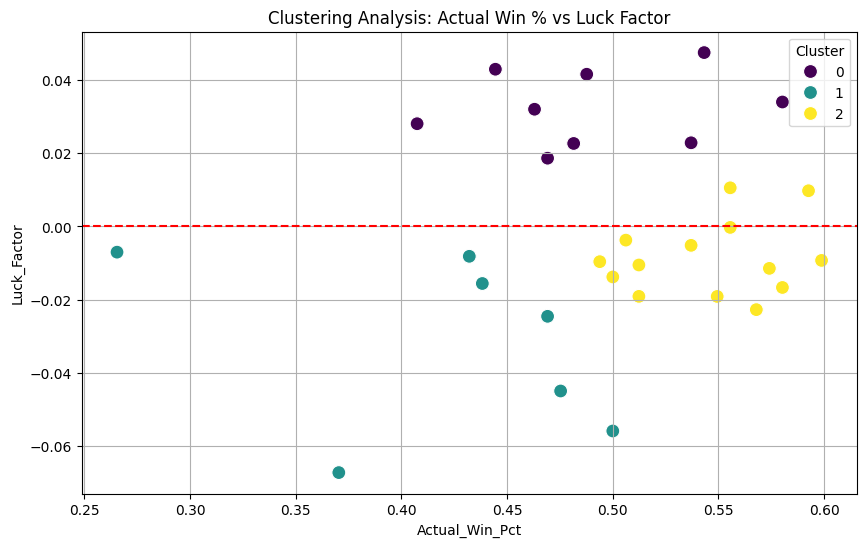

In [9]:
# 클러스터별 평균 지표 계산
cluster_analysis = df.groupby('Cluster')[['Actual_Win_Pct', 'Luck_Factor', 'Pythagorean_Win_Pct']].mean()
print("--- 클러스터별 평균 지표 비교 ---")
print(cluster_analysis.round(3))

# 시각화: 어떤 차이로 나뉘었는지 산점도로 확인
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Actual_Win_Pct', y='Luck_Factor', hue='Cluster', palette='viridis', s=100)
plt.axhline(0, color='red', linestyle='--') # Luck_Factor 0 지점 (기준선)
plt.title('Clustering Analysis: Actual Win % vs Luck Factor')
plt.grid(True)
plt.show()

In [4]:
import plotly.express as px

# 1. 인터랙티브 산점도 생성
fig = px.scatter(
    df, 
    x='Actual_Win_Pct', 
    y='Luck_Factor', 
    color='Cluster',          # 클러스터별 색상 구분
    hover_name='Team',          # 마우스 올리면 팀 이름 표시
    hover_data=['W', 'L', 'Pythagorean_Win_Pct'], # 추가 정보 표시
    text='Team',                # 점 옆에 팀명 상시 표시 (선택 사항)
    title="2025 MLB 클러스터 분석: 실제 승률 vs Luck Factor",
    labels={'Actual_Win_Pct': '실제 승률 (Actual Win %)', 'Luck_Factor': '운/불운 지표 (Luck Factor)'},
    color_continuous_scale=px.colors.qualitative.Pastel # 색상 테마
)

# 가이드라인 (Luck Factor 0 지점)
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="지표 수렴 기준선")

fig.update_traces(textposition='top center', marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    template='plotly_white',
    xaxis_tickformat='.3f',
    yaxis_tickformat='.3f'
)

# 4. 그래프 출력
fig.show()

# (선택) HTML 파일로 저장해서 웹브라우저로 보고 싶다면:
# fig.write_html("mlb_cluster_analysis.html")

In [5]:
df

,Team,W,L,R,RA,Actual_Win_Pct,Pythagorean_Win_Pct,Luck_Factor,Cluster
0,Blue Jays,94,68,798,721,0.580247,0.546289,0.033958,0
1,Yankees,94,68,849,685,0.580247,0.596955,-0.016708,2
2,Red Sox,89,73,786,676,0.549383,0.568540,-0.019157,2
3,Rays,77,85,714,683,0.475309,0.520296,-0.044988,1
4,Orioles,75,87,677,788,0.462963,0.430983,0.031980,0
5,Guardians,88,74,643,649,0.543210,0.495751,0.047459,0
6,Tigers,87,75,758,691,0.537037,0.542238,-0.005201,2
7,Royals,82,80,651,637,0.506173,0.509945,-0.003772,2
8,Twins,70,92,678,773,0.432099,0.440293,-0.008195,1
9,White Sox,60,102,647,742,0.370370,0.437647,-0.067277,1


In [5]:
import pybaseball as pyb
import pandas as pd

# 1. 데이터 로드 및 전처리
rangers_rec = pyb.schedule_and_record(2025, 'TEX')
rangers_rec['R'] = pd.to_numeric(rangers_rec['R'], errors='coerce')
rangers_rec['RA'] = pd.to_numeric(rangers_rec['RA'], errors='coerce')

# 2. 홈/원정 구분 컬럼 생성 (기존 데이터의 빈칸은 홈, '@'는 원정)
rangers_rec['Venue'] = rangers_rec['Home_Away'].apply(lambda x: 'Away' if x == '@' else 'Home')

# 3. 1점 차 경기 필터링
one_run_games = rangers_rec[abs(rangers_rec['R'] - rangers_rec['RA']) == 1].copy()

# 4. 홈 vs 원정 성적 비교 분석
venue_stats = one_run_games.groupby(['Venue', 'W/L']).size().unstack(fill_value=0)

print("=== 텍사스 레인저스 1점 차 승부 (장소별) ===")
print(venue_stats)

# 홈/원정 승률 계산
for venue in ['Home', 'Away']:
    w = (one_run_games[(one_run_games['Venue'] == venue) & (one_run_games['W/L'].str.startswith('W'))]).shape[0]
    total = (one_run_games[one_run_games['Venue'] == venue]).shape[0]
    if total > 0:
        print(f"{venue} 1점 차 승률: {w/total:.3f} ({total}경기 중 {w}승)")

http://www.baseball-reference.com/teams/TEX/2025-schedule-scores.shtml
=== 텍사스 레인저스 1점 차 승부 (장소별) ===
W/L     L  L-wo  W  W-wo
Venue                   
Away    7    10  6     0
Home   11     0  7     8
Home 1점 차 승률: 0.577 (26경기 중 15승)
Away 1점 차 승률: 0.261 (23경기 중 6승)


/Users/jisoyun/Desktop/Final_Baseball/.venv/lib/python3.12/site-packages/pybaseball/team_results.py:75: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


In [6]:
import pybaseball as pyb
import pandas as pd

# 1. 2025년 텍사스 전체 경기 데이터 가져오기
print("텍사스 레인저스 시즌 데이터 로드 중...")
rangers_rec = pyb.schedule_and_record(2025, 'TEX')

# 2. 데이터 전처리 (득점/실점 숫자 변환)
rangers_rec['R'] = pd.to_numeric(rangers_rec['R'], errors='coerce')
rangers_rec['RA'] = pd.to_numeric(rangers_rec['RA'], errors='coerce')
rangers_rec = rangers_rec.dropna(subset=['R', 'RA'])

# 3. 홈/원정 구분 컬럼 생성
rangers_rec['Venue'] = rangers_rec['Home_Away'].apply(lambda x: 'Away' if x == '@' else 'Home')

# 4. 결과(Win/Loss) 정리 (W-wo, L-wo 등을 Win, Loss로 통일)
rangers_rec['Result'] = rangers_rec['W/L'].apply(lambda x: 'Win' if x.startswith('W') else 'Loss')

# 5. 전체 시즌 홈/원정 성적 계산
overall_stats = rangers_rec.groupby(['Venue', 'Result']).size().unstack(fill_value=0)
overall_stats['Total'] = overall_stats['Win'] + overall_stats['Loss']
overall_stats['Win_Rate'] = overall_stats['Win'] / overall_stats['Total']

# 6. 1점 차 경기만 따로 필터링해서 분석
one_run_games = rangers_rec[abs(rangers_rec['R'] - rangers_rec['RA']) == 1].copy()
one_run_stats = one_run_games.groupby(['Venue', 'Result']).size().unstack(fill_value=0)
one_run_stats['Total'] = one_run_stats['Win'] + one_run_stats['Loss']
one_run_stats['Win_Rate'] = one_run_stats['Win'] / one_run_stats['Total']

# --- 결과 출력 ---
print("\n" + "="*40)
print("  2025 텍사스 레인저스 홈/원정 전체 성적")
print("="*40)
print(overall_stats[['Win', 'Loss', 'Total', 'Win_Rate']].round(3))

print("\n" + "="*40)
print("  2025 텍사스 레인저스 1점 차 승부 성적")
print("="*40)
print(one_run_stats[['Win', 'Loss', 'Total', 'Win_Rate']].round(3))

텍사스 레인저스 시즌 데이터 로드 중...
http://www.baseball-reference.com/teams/TEX/2025-schedule-scores.shtml

  2025 텍사스 레인저스 홈/원정 전체 성적
Result  Win  Loss  Total  Win_Rate
Venue                             
Away     33    47     80     0.412
Home     48    33     81     0.593

  2025 텍사스 레인저스 1점 차 승부 성적
Result  Win  Loss  Total  Win_Rate
Venue                             
Away      6    17     23     0.261
Home     15    11     26     0.577


/Users/jisoyun/Desktop/Final_Baseball/.venv/lib/python3.12/site-packages/pybaseball/team_results.py:75: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


/var/folders/wc/4jpr72gn34v7gndmn2_zk9680000gn/T/ipykernel_90660/2992126622.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Home_Rate', data=df, ax=ax[0], palette='Blues')
/var/folders/wc/4jpr72gn34v7gndmn2_zk9680000gn/T/ipykernel_90660/2992126622.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Away_Rate', data=df, ax=ax[1], palette='Reds')


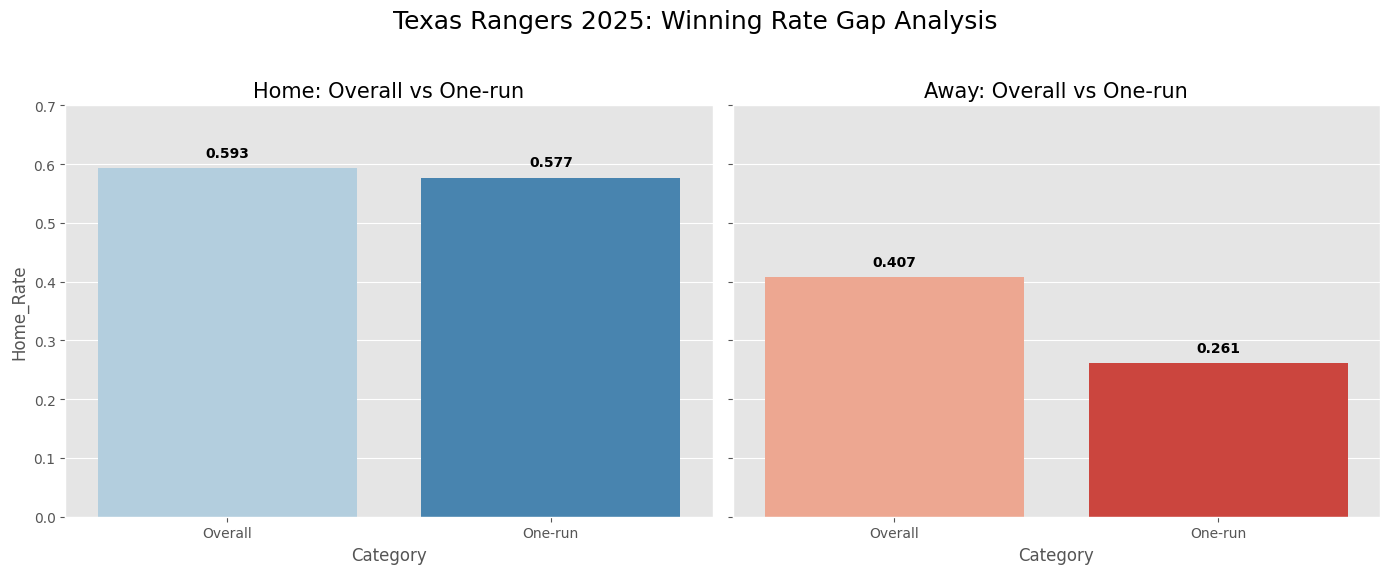

=== 원정 경기 승률 차이 통계 분석 ===
전체 원정 승률: 0.407
1점 차 원정 승률: 0.261
P-value: 0.2002

결과: 통계적으로 유의미한 차이가 없습니다. (일시적인 불운일 확률이 높음)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# 1. 데이터 설정 (앞서 분석한 수치 기반)
data = {
    'Category': ['Overall', 'One-run'],
    'Home_Wins': [48, 15],
    'Home_Total': [81, 26],
    'Away_Wins': [33, 6],
    'Away_Total': [81, 23]
}

df = pd.DataFrame(data)
df['Home_Rate'] = df['Home_Wins'] / df['Home_Total']
df['Away_Rate'] = df['Away_Wins'] / df['Away_Total']

# 2. 통계적 유의성 검정 (Z-Test)
# 원정 전체 승률 vs 원정 1점차 승률의 차이가 우연인가?
count = np.array([33, 6])
nobs = np.array([81, 23])
stat, pval = proportions_ztest(count, nobs)

# 3. 시각화 (그래프 생성)
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 홈 경기 그래프
sns.barplot(x='Category', y='Home_Rate', data=df, ax=ax[0], palette='Blues')
ax[0].set_title('Home: Overall vs One-run', fontsize=15)
ax[0].set_ylim(0, 0.7)
for i, v in enumerate(df['Home_Rate']):
    ax[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 원정 경기 그래프
sns.barplot(x='Category', y='Away_Rate', data=df, ax=ax[1], palette='Reds')
ax[1].set_title('Away: Overall vs One-run', fontsize=15)
for i, v in enumerate(df['Away_Rate']):
    ax[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Texas Rangers 2025: Winning Rate Gap Analysis', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. 통계 결과 출력
print(f"=== 원정 경기 승률 차이 통계 분석 ===")
print(f"전체 원정 승률: {df['Away_Rate'][0]:.3f}")
print(f"1점 차 원정 승률: {df['Away_Rate'][1]:.3f}")
print(f"P-value: {pval:.4f}")

if pval < 0.05:
    print("\n결과: 통계적으로 유의미한 차이가 발견되었습니다. (단순 불운보다는 구조적 문제 가능성)")
else:
    print("\n결과: 통계적으로 유의미한 차이가 없습니다. (일시적인 불운일 확률이 높음)")
    

/var/folders/wc/4jpr72gn34v7gndmn2_zk9680000gn/T/ipykernel_90660/2544206427.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


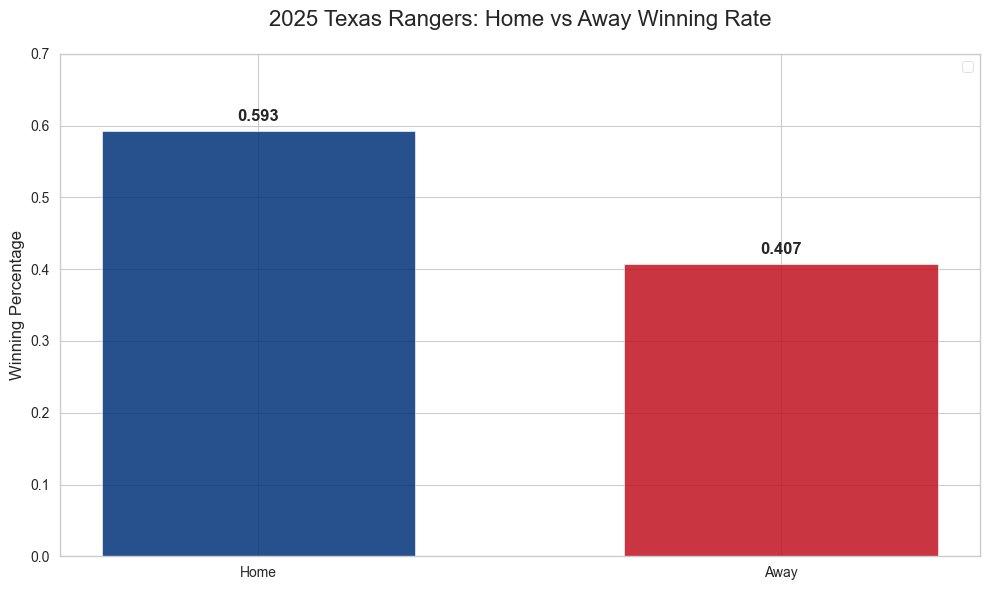

=== 2025 텍사스 레인저스 장소별 승률 통계 ===
홈 승률: 0.593
원정 승률: 0.407
두 장소 간 승률 격차: 0.185
통계적 유의성 (P-value): 0.0184

[분석 결과] 통계적으로 매우 유의미한 차이가 있습니다.
단순한 운이 아니라, 구장 환경(The Shed)이나 장소에 따른 경기력 편차가 실존함이 증명되었습니다.


In [17]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

# 1. 데이터 설정 (2025 시즌 최종 성적 기반)
data = {
    'Venue': ['Home', 'Away'],
    'Wins': [48, 33],
    'Total_Games': [81, 81]
}

df = pd.DataFrame(data)
df['Win_Rate'] = df['Wins'] / df['Total_Games']

# 2. 통계 분석 (홈 승률 vs 원정 승률 차이 검정)
# "홈과 원정의 승률 차이가 우연인가?"를 검정
count = df['Wins'].values
nobs = df['Total_Games'].values
z_stat, p_val = proportions_ztest(count, nobs)

# 3. 시각화 (Home vs Away Winning Rate)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 막대 그래프 생성
colors = ['#003278', '#C0111F'] # 텍사스 레인저스 팀 컬러 (Blue, Red)
bars = plt.bar(df['Venue'], df['Win_Rate'], color=colors, alpha=0.85, width=0.6)

# 수치 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# 그래프 꾸미기
plt.title('2025 Texas Rangers: Home vs Away Winning Rate', fontsize=16, pad=20)
plt.ylabel('Winning Percentage', fontsize=12)
plt.ylim(0, 0.7)
#plt.axhline(0.500, color='black', linestyle='--', alpha=0.5, label='League Average (.500)')
plt.legend()

plt.tight_layout()
plt.show()

# 4. 분석 결과 출력
print(f"=== 2025 텍사스 레인저스 장소별 승률 통계 ===")
print(f"홈 승률: {df.loc[0, 'Win_Rate']:.3f}")
print(f"원정 승률: {df.loc[1, 'Win_Rate']:.3f}")
print(f"두 장소 간 승률 격차: {abs(df.loc[0, 'Win_Rate'] - df.loc[1, 'Win_Rate']):.3f}")
print(f"통계적 유의성 (P-value): {p_val:.4f}")

if p_val < 0.05:
    print("\n[분석 결과] 통계적으로 매우 유의미한 차이가 있습니다.")
    print("단순한 운이 아니라, 구장 환경(The Shed)이나 장소에 따른 경기력 편차가 실존함이 증명되었습니다.")
else:
    print("\n[분석 결과] 통계적으로 유의미한 차이까지는 아닙니다. (일시적 현상일 수 있음)")